In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn.functional as F
from groupy import *
from matplotlib.patches import Polygon

# R^2/Z_2 Visualization

## Load data and compute embedded data

In [94]:
N = 1000

# Set device
device = torch.device('cpu')

# Load trained parameters
templates_np = np.load('templates_trained_4.npy')
L_np = np.load('L_trained_4.npy')

templates = torch.from_numpy(templates_np).float().to(device)
L = torch.from_numpy(L_np).float().to(device)

# Normalize templates
norm_templates = F.normalize(templates, dim=1)

# Load your input X (shape: d x n)
X_np = np.random.normal(1, 1, size=(2, N))
X = torch.from_numpy(X_np).float().to(device)

# Define your group (use the same pmId you used in training)
G = GPU_GroupAction(pmId, X.shape[0], device=device, dtype=torch.float32)
X_orbits = G.get_orbits(X)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = max_filter(norm_templates, X_orbits)
    output = L @ filtered_features  # shape: target_dim x n

# If you want it as numpy array
Y = output.cpu().numpy()

# Visualize in 3D using PCA

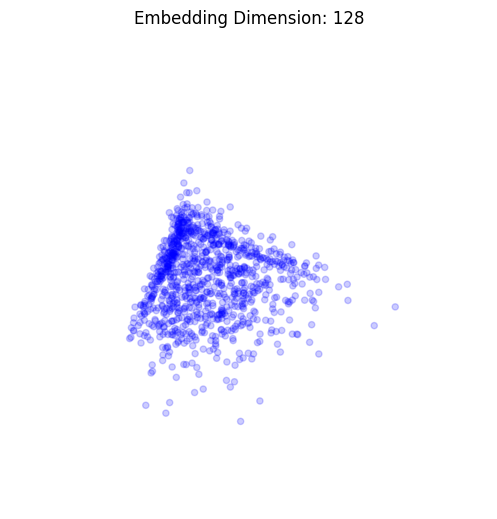

In [95]:
# X_np: original input, shape (2, n_samples)
# Y: model output, shape (target_dim, n_samples)
Y_T = Y.T  # shape: (n_samples, target_dim)

# PCA for Y to 3D
n_comp_Y = min(3, Y_T.shape[0], Y_T.shape[1])
pca_Y = PCA(n_components=n_comp_Y)
Y_pca = pca_Y.fit_transform(Y_T)
if Y_pca.shape[1] < 3:
    padded = np.zeros((Y_pca.shape[0], 3))
    padded[:, :Y_pca.shape[1]] = Y_pca
    Y_pca = padded

# Side-by-side scatterplots
ax = plt.figure(figsize = (5,5)).add_subplot(projection='3d')
ax.scatter(Y_pca[:, 0], Y_pca[:, 1], Y_pca[:, 2], c='blue', alpha=0.2)
ax.view_init(elev=50 ,azim=170)
ax.set_axis_off()
ax.set_title("Embedding Dimension: 128")
plt.tight_layout(pad=0)
plt.savefig("Z2_ed128.png")

# R^2/Z_2 Polytope Visualization 

In [147]:
# sample Gauassian point, apply LMF map, obtain the top 2 prinipal components in the embedding space 
N = 1000
device = torch.device('cpu')
t = 8

# Load trained parameters
templates_np = np.load(f'templates_trained_{t}.npy')
L_np = np.load(f'L_trained_{t}.npy')
templates = torch.from_numpy(templates_np).float().to(device)
L = torch.from_numpy(L_np).float().to(device)
norm_templates = F.normalize(templates, dim=1)

X_np = np.random.normal(1, 1, size=(2, N))
X = torch.from_numpy(X_np).float().to(device)

G = GPU_GroupAction(pmId, X.shape[0], device=device, dtype=torch.float32)
X_orbits = G.get_orbits(X)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = max_filter(norm_templates, X_orbits)
    output = L @ filtered_features  # shape: target_dim x n
Y = output.cpu().numpy()

Y_centered = (Y.T - np.mean(Y,axis = 1)).T

# PCA without centering (just finding best 2-dim subspace and projecting onto it orthogonally)
U, S,V = np.linalg.svd(Y_centered) 
components = U[:, :3]

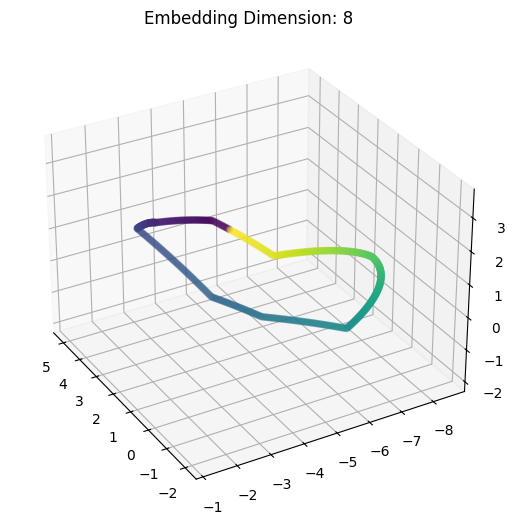

In [148]:
# sample S^1 uniformly, apply LMF map, orthgonally project onto prev found 2 prinipal components in the embedding space 
phi = np.linspace(0, np.pi, N)
X_np = np.vstack([np.cos(phi), np.sin(phi)])
X = torch.from_numpy(X_np).float().to(device)
X_orbits = G.get_orbits(X)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = max_filter(norm_templates, X_orbits)
    output = L @ filtered_features  # shape: target_dim x n
Y = output.cpu().numpy()
Y_pca = (Y.T @ components)

# Side-by-side scatterplots
ax = plt.figure(figsize = (5,5)).add_subplot(projection='3d')
ax.scatter(Y_pca[:, 0], Y_pca[:, 1], Y_pca[:, 2], c=phi, alpha=0.2)
ax.set_title(f"Embedding Dimension: {t}")
ax.view_init(elev=30 ,azim=150)
plt.tight_layout(pad=0)
plt.axis('equal')

plt.savefig(f'Z2_ed{t}.png')

 ## Creating the cone visualization by finding hyperplanes and their intersections

In [149]:
from sklearn.cluster import KMeans

def plane_normal(pts):
    a, b, c = pts
    n = np.cross(b - a, c - a)
    return n/np.linalg.norm(n)

# handles cyclicity
Ystack = np.vstack([Y_pca, Y_pca])
normals = np.array([plane_normal(Ystack[[i,i+1,i+2], :]) for i in range(N+20)])

# denoise the normals to get the true hyperplanes 
TOL = 1e-2
denoised_normals = np.array([normals[i] for i in range(N) if 
                             np.linalg.norm(normals[i] - normals[i+1]) < TOL and np.linalg.norm(normals[i] - normals[i-1]) < TOL])

kmeans = KMeans(n_clusters=t).fit(denoised_normals)
clustered_normals = kmeans.cluster_centers_

# find closest cluster for each normal 
dists = np.linalg.norm(denoised_normals[:, None, :] - clustered_normals[None, :, :], axis=2)
idx = np.argmin(dists, axis=1)
# all this is just to reorder the normals in their original order after clustering 
_, idx2 = np.unique(clustered_normals[idx], axis=0,return_index=True)
normals = clustered_normals[idx][np.sort(idx2)]

C:\Users\Nathan\AppData\Local\Temp\ipykernel_24024\460176308.py:6: RuntimeWarning: invalid value encountered in divide
  return n/np.linalg.norm(n)


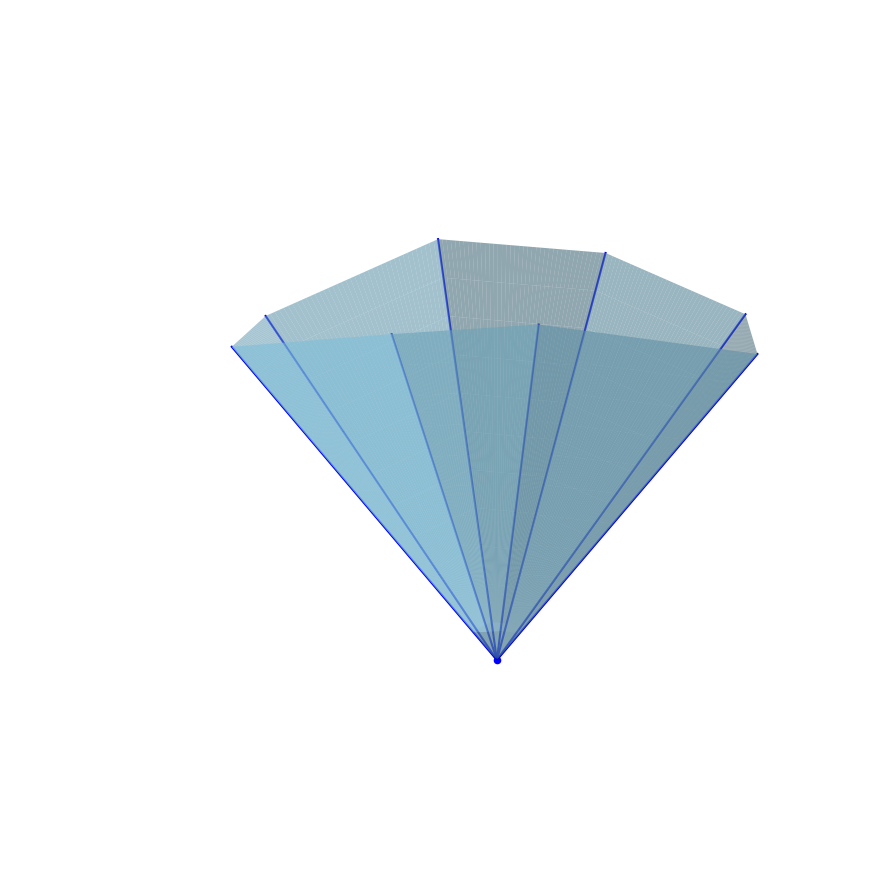

In [157]:
n = normals.T.astype("double")
M = n.shape[1]
eps = 1e-8

# compute intersection directions between consecutive planes
inter = np.zeros((3, M))
for i in range(M):
    v = np.cross(n[:, i], n[:, (i+1) % M])
    nv = np.linalg.norm(v)
    inter[:, i] = v / nv

# plot cone
fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

R = 1.0  # radial extent

# iteratively flip signs so each intersection ray has positive dot with its neighbor
max_iters = 2 * M
for _ in range(max_iters):
    changed = False
    for i in range(M):
        a = inter[:, i]; b = inter[:, (i+1) % M]
        if np.linalg.norm(a) < eps or np.linalg.norm(b) < eps:
            continue
        if np.dot(a, b) < 0:
            inter[:, (i+1) % M] *= -1
            changed = True
    if not changed:
        break

# plot each plane between its two neighboring intersection rays
for i in range(M):
    a = inter[:, (i-1) % M]
    b = inter[:, i]
    if np.linalg.norm(a) < eps or np.linalg.norm(b) < eps:
        continue
    s = np.linspace(0, 1, 40)
    r = np.linspace(0, R, 12)
    S, Rg = np.meshgrid(s, r)
    P = ((1 - S)[..., None] * a + S[..., None] * b) * Rg[..., None]
    X, Y, Z = P[...,0], P[...,1], P[...,2]
    ax.plot_surface(X, Y, Z, alpha=0.6, linewidth=0, rstride=1, cstride=1, color='skyblue')

# plot intersection rays from origin outward
ts = np.linspace(0, R, 20)
for i in range(M):
    d = inter[:, i]
    if np.linalg.norm(d) < eps:
        continue
    pts = np.outer(ts, d)
    ax.plot(pts[:,0], pts[:,1], pts[:,2], color='blue', linewidth=1.5)

# origin
ax.scatter([0],[0],[0], color='blue', s=20)

# set view
ax.view_init(elev=120, azim=-70)
ax.set_axis_off()

plt.tight_layout()
plt.axis('equal')
plt.savefig(f'Z2_cone_ed{t}.png')

# Visualizing Districts 

## Load district outlines and compute embedded data

In [2]:
districts = np.load('district_outlines.npy')

device = torch.device('cpu')

# Load trained parameters
templates_np = np.load('templates_trained_districts.npy')
L_np = np.load('L_trained_districts.npy')

templates = torch.from_numpy(templates_np).to(torch.complex64).to(device)
L = torch.from_numpy(L_np).float().to(device)

# Normalize templates
norm_templates = F.normalize(templates, dim=1)

X = torch.from_numpy(districts).to(torch.complex64).to(device)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = shape_max_filter(norm_templates, X)
    output = L @ filtered_features  # shape: target_dim x n

# If you want it as numpy array
Y = output.cpu().numpy()

# Visualize Districts with PCA

Sources: https://thefulcrum.us/electoral-reforms/worst-gerrymandered-districts, https://www.statista.com/chart/21313/most-gerrymandered-districts-us/?srsltid=AfmBOorzzt2FBKgoE2JATcnhMU6aFW3Dqsm-gnFFQTGRrTKE9tHMmUx5
(Maryland 3rd was redone since the 2nd infographic) 

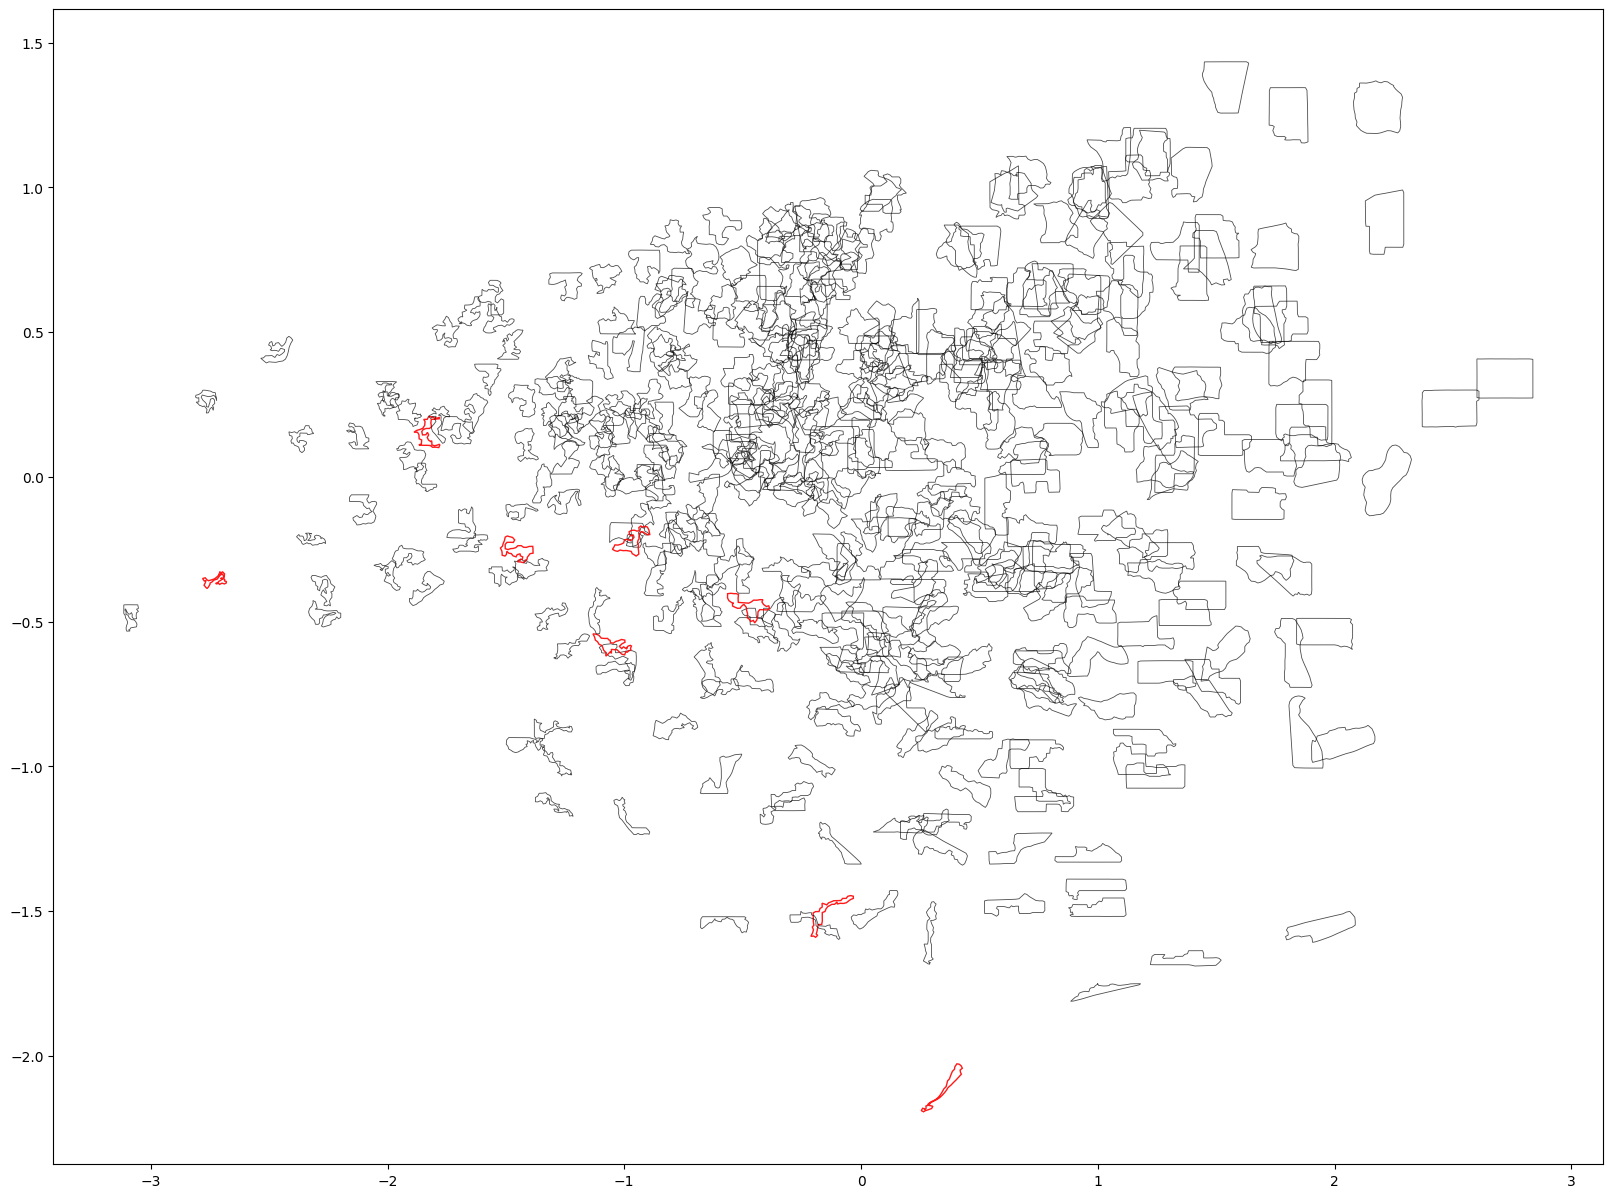

In [20]:
districts_coords = districts.T

def place_complex_outline(ax, pca_point, complex_coords, shape_scale=1,
                          edgecolor='k', alpha=0.8, linewidth=0.5):
    """Draw polygon from complex coords centered & scaled at pca_point."""
    arr = np.asarray(complex_coords)
    if arr.ndim == 1 and np.iscomplexobj(arr):
        verts = np.vstack([arr.real, arr.imag]).T
    elif arr.ndim == 2 and arr.shape[1] == 2:
        verts = arr.astype(float)
    else:
        raise ValueError("complex_coords must be 1D complex or (N,2) real array")

    centroid = verts.mean(axis=0)
    verts = (verts - centroid) * shape_scale + np.asarray(pca_point)[None, :]
    poly = Polygon(verts, closed=True, facecolor='none',
                   edgecolor=edgecolor, alpha=alpha, linewidth=linewidth)
    ax.add_patch(poly)
    return poly

# --- usage (minimal) ---
# Y: shape (features, samples); districts_coords: list/array of complex arrays
Y_T = Y.T
pca = PCA(n_components=2)
Y_pca = pca.fit_transform(Y_T)

fig, ax = plt.subplots(figsize=(20, 15))
ax.scatter(Y_pca[:, 0], Y_pca[:, 1], facecolors='none', edgecolors='lightgray', alpha=0)

# scale based on PCA spread (matches your original approach)
pca_ranges = Y_pca.max(0) - Y_pca.min(0)
shape_scale = np.mean(pca_ranges) * .16

subset_fraction = 1
n = Y_pca.shape[0]
subset_idx = np.random.choice(n, max(1, int(n * subset_fraction)), replace=False)

# illinois 13, illinois 17, illinois 4, ohio 15, texas 35, texas 33, tennessee 05, louisianna 2, 
highlight_indices = [139, 143, 130, 305, 385, 383, 346, 130, 168]

for i in subset_idx:
    if i in highlight_indices:
        color = 'red'  # highlight color
        alpha_val = 0.9
        lw = 1.0
    else:
        color = 'k'    # default black
        alpha_val = 0.7
        lw = 0.6

    place_complex_outline(ax, Y_pca[i, :2], districts_coords[i],
                          shape_scale=shape_scale, edgecolor=color,
                          alpha=alpha_val, linewidth=lw)

# automatic margins instead of hard-coded limits
x0, x1 = Y_pca[:,0].min(), Y_pca[:,0].max()
y0, y1 = Y_pca[:,1].min(), Y_pca[:,1].max()

# ax.set_title("Embedded Congressional Districts (PCA)")
plt.savefig("district_embeddings.png", dpi=300, bbox_inches='tight')
plt.show()